In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from urllib.request import urlopen
import plotly.graph_objects as gos
from plotly.subplots import make_subplots
import json
import gc
import helper

weather_data_directory = "./dataset/WRF-HRRR Dataset"
crop_data_directory = "./dataset/USDA Crop Dataset/data"


In [3]:
selected_states = {}
with open("selected_states.json") as file:
    selected_states = json.load(file)
    
print(selected_states)

{'TX': 'TEXAS', 'CA': 'CALIFORNIA', 'SD': 'SOUTH DAKOTA', 'ND': 'NORTH DAKOTA', 'AR': 'ARKANSAS', 'KS': 'KANSAS'}


In [5]:
def visualize_production_distribution(data, x_label="PRODUCTION, MEASURED IN BU", title=""):
    plt.figure(figsize=(8, 4))
    sns.histplot(data, bins=50, kde=True, color='green')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## 1. Load Dataset

### 1.2 Load Crop Production Dataset

#### 1.2.1 Corn Production

In [32]:
corn_production_data = helper.load_all_crop_production_data(crop_data_directory, selected_states.values(), "Corn")
corn_production_data["fips_code"] = corn_production_data.apply(helper.generate_fips_code, axis=1)
corn_production_data["harvested_area"] = corn_production_data.apply(helper.calculate_acre_from_production, axis=1)
corn_production_data

Loaded Corn production data from 6 states


,commodity_desc,reference_period_desc,year,state_ansi,state_name,county_ansi,county_name,asd_code,asd_desc,domain_desc,source_desc,agg_level_desc,"PRODUCTION, MEASURED IN BU","YIELD, MEASURED IN BU / ACRE",fips_code,harvested_area
0,CORN,YEAR,2017,5,ARKANSAS,1,ARKANSAS,60,EAST CENTRAL,TOTAL,SURVEY,COUNTY,8885000.0,192.3,05001,46203.848154
1,CORN,YEAR,2017,5,ARKANSAS,3,ASHLEY,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,4905000.0,196.2,05003,25000.000000
2,CORN,YEAR,2017,5,ARKANSAS,17,CHICOT,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,3630000.0,182.4,05017,19901.315789
3,CORN,YEAR,2017,5,ARKANSAS,21,CLAY,30,NORTHEAST,TOTAL,SURVEY,COUNTY,6205000.0,203.4,05021,30506.391347
4,CORN,YEAR,2017,5,ARKANSAS,31,CRAIGHEAD,30,NORTHEAST,TOTAL,SURVEY,COUNTY,6045000.0,185.4,05031,32605.177994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,CORN,YEAR,2022,48,TEXAS,469,VICTORIA,90,UPPER COAST,TOTAL,SURVEY,COUNTY,2519000.0,74.3,48469,33903.095559
1417,CORN,YEAR,2022,48,TEXAS,473,WALLER,52,EAST TEXAS SOUTH,TOTAL,SURVEY,COUNTY,117300.0,60.2,48473,1948.504983
1418,CORN,YEAR,2022,48,TEXAS,481,WHARTON,90,UPPER COAST,TOTAL,SURVEY,COUNTY,6637000.0,77.4,48481,85749.354005
1419,CORN,YEAR,2022,48,TEXAS,491,WILLIAMSON,40,BLACKLANDS,TOTAL,SURVEY,COUNTY,4343000.0,52.2,48491,83199.233716


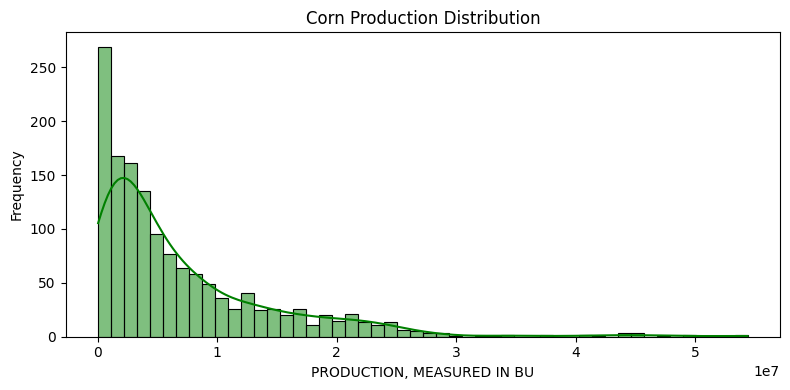

In [7]:
visualize_production_distribution(corn_production_data["PRODUCTION, MEASURED IN BU"], "PRODUCTION, MEASURED IN BU", "Corn Production Distribution")

#### 1.2.2 Cotton Production

In [31]:
cotton_production_data = helper.load_all_crop_production_data(crop_data_directory, selected_states.values(), "Cotton")
cotton_production_data["fips_code"] = cotton_production_data.apply(helper.generate_fips_code, axis=1)
cotton_production_data["harvested_area"] = cotton_production_data.apply(helper.calculate_acre_from_production, axis=1)
cotton_production_data

Loaded Cotton production data from 4 states


,commodity_desc,reference_period_desc,year,state_ansi,state_name,county_ansi,county_name,asd_code,asd_desc,domain_desc,source_desc,agg_level_desc,"PRODUCTION, MEASURED IN 480 LB BALES","YIELD, MEASURED IN LB / ACRE",fips_code,harvested_area
0,COTTON,YEAR,2017,5,ARKANSAS,3,ASHLEY,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,55700.0,1133.0,05003,49.161518
1,COTTON,YEAR,2017,5,ARKANSAS,17,CHICOT,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,34400.0,995.0,05017,34.572864
2,COTTON,YEAR,2017,5,ARKANSAS,21,CLAY,30,NORTHEAST,TOTAL,SURVEY,COUNTY,85400.0,1340.0,05021,63.731343
3,COTTON,YEAR,2017,5,ARKANSAS,31,CRAIGHEAD,30,NORTHEAST,TOTAL,SURVEY,COUNTY,163000.0,1175.0,05031,138.723404
4,COTTON,YEAR,2017,5,ARKANSAS,35,CRITTENDEN,60,EAST CENTRAL,TOTAL,SURVEY,COUNTY,46400.0,1142.0,05035,40.630473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,COTTON,YEAR,2022,48,TEXAS,487,WILBARGER,21,NORTHERN LOW PLAINS,TOTAL,SURVEY,COUNTY,21300.0,859.0,48487,24.796275
666,COTTON,YEAR,2022,48,TEXAS,489,WILLACY,97,LOWER VALLEY,TOTAL,SURVEY,COUNTY,101100.0,724.0,48489,139.640884
667,COTTON,YEAR,2022,48,TEXAS,491,WILLIAMSON,40,BLACKLANDS,TOTAL,SURVEY,COUNTY,10500.0,434.0,48491,24.193548
668,COTTON,YEAR,2022,48,TEXAS,501,YOAKUM,12,SOUTHERN HIGH PLAINS,TOTAL,SURVEY,COUNTY,22000.0,416.0,48501,52.884615


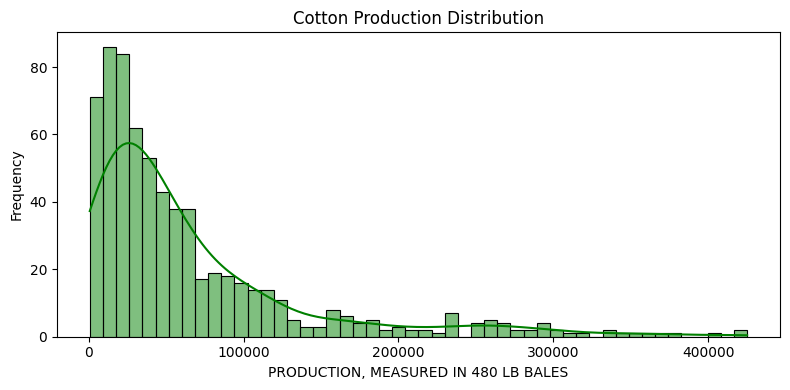

In [9]:
visualize_production_distribution(cotton_production_data["PRODUCTION, MEASURED IN 480 LB BALES"], "PRODUCTION, MEASURED IN 480 LB BALES", "Cotton Production Distribution")

#### 1.2.3 Soybeans Production

In [30]:
soybeans_production_data = helper.load_all_crop_production_data(crop_data_directory, selected_states.values(), "Soybean")
soybeans_production_data["fips_code"] = soybeans_production_data.apply(helper.generate_fips_code, axis=1)
soybeans_production_data["harvested_area"] = soybeans_production_data.apply(helper.calculate_acre_from_production, axis=1)
soybeans_production_data

Loaded Soybean production data from 5 states


,commodity_desc,reference_period_desc,year,state_ansi,state_name,county_ansi,county_name,asd_code,asd_desc,domain_desc,source_desc,agg_level_desc,"PRODUCTION, MEASURED IN BU","YIELD, MEASURED IN BU / ACRE",fips_code,harvested_area
0,SOYBEANS,YEAR,2017,5,ARKANSAS,1,ARKANSAS,60,EAST CENTRAL,TOTAL,SURVEY,COUNTY,10040000.0,53.7,05001,186964.618250
1,SOYBEANS,YEAR,2017,5,ARKANSAS,3,ASHLEY,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,3490000.0,56.8,05003,61443.661972
2,SOYBEANS,YEAR,2017,5,ARKANSAS,17,CHICOT,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,8647000.0,51.2,05017,168886.718750
3,SOYBEANS,YEAR,2017,5,ARKANSAS,21,CLAY,30,NORTHEAST,TOTAL,SURVEY,COUNTY,6583000.0,54.8,05021,120127.737226
4,SOYBEANS,YEAR,2017,5,ARKANSAS,29,CONWAY,50,CENTRAL,TOTAL,SURVEY,COUNTY,745000.0,39.4,05029,18908.629442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,SOYBEANS,YEAR,2022,48,TEXAS,147,FANNIN,40,BLACKLANDS,TOTAL,SURVEY,COUNTY,63000.0,16.8,48147,3750.000000
1076,SOYBEANS,YEAR,2022,48,TEXAS,277,LAMAR,40,BLACKLANDS,TOTAL,SURVEY,COUNTY,110000.0,12.0,48277,9166.666667
1077,SOYBEANS,YEAR,2022,48,TEXAS,357,OCHILTREE,11,NORTHERN HIGH PLAINS,TOTAL,SURVEY,COUNTY,139000.0,39.8,48357,3492.462312
1078,SOYBEANS,YEAR,2022,48,TEXAS,469,VICTORIA,90,UPPER COAST,TOTAL,SURVEY,COUNTY,34500.0,14.5,48469,2379.310345


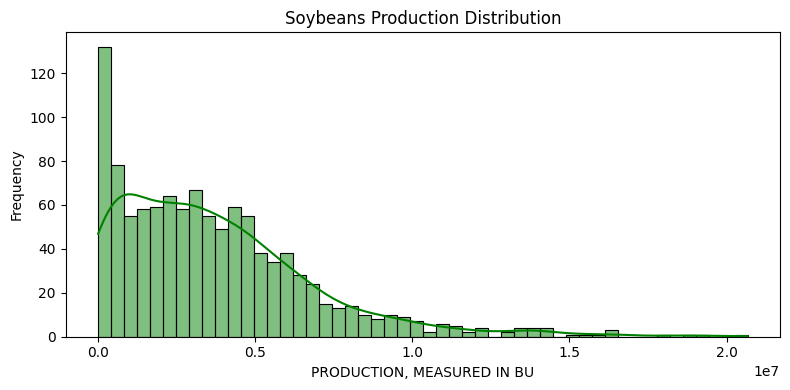

In [11]:
visualize_production_distribution(data=soybeans_production_data["PRODUCTION, MEASURED IN BU"], 
                                  x_label="PRODUCTION, MEASURED IN BU", 
                                  title="Soybeans Production Distribution")

#### 1.2.3 Winter Wheat Production

In [29]:
wheat_production_data = helper.load_all_crop_production_data(crop_data_directory, selected_states.values(), "WinterWheat")
wheat_production_data["fips_code"] = wheat_production_data.apply(helper.generate_fips_code, axis=1)
wheat_production_data["harvested_area"] = wheat_production_data.apply(helper.calculate_acre_from_production, axis=1)
wheat_production_data


Loaded WinterWheat production data from 6 states


,commodity_desc,reference_period_desc,year,state_ansi,state_name,county_ansi,county_name,asd_code,asd_desc,domain_desc,source_desc,agg_level_desc,"PRODUCTION, MEASURED IN BU","YIELD, MEASURED IN BU / ACRE",fips_code,harvested_area
0,WHEAT,YEAR,2017,5,ARKANSAS,3,ASHLEY,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,76000.0,63.3,05003,1200.631912
1,WHEAT,YEAR,2017,5,ARKANSAS,37,CROSS,60,EAST CENTRAL,TOTAL,SURVEY,COUNTY,282000.0,65.6,05037,4298.780488
2,WHEAT,YEAR,2017,5,ARKANSAS,69,JEFFERSON,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,240000.0,44.4,05069,5405.405405
3,WHEAT,YEAR,2017,5,ARKANSAS,77,LEE,60,EAST CENTRAL,TOTAL,SURVEY,COUNTY,225000.0,47.9,05077,4697.286013
4,WHEAT,YEAR,2017,5,ARKANSAS,79,LINCOLN,90,SOUTHEAST,TOTAL,SURVEY,COUNTY,206000.0,45.8,05079,4497.816594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194,WHEAT,YEAR,2022,48,TEXAS,491,WILLIAMSON,40,BLACKLANDS,TOTAL,SURVEY,COUNTY,233000.0,34.9,48491,6676.217765
1195,WHEAT,YEAR,2022,48,TEXAS,493,WILSON,81,SOUTH CENTRAL,TOTAL,SURVEY,COUNTY,5000.0,21.7,48493,230.414747
1196,WHEAT,YEAR,2022,48,TEXAS,497,WISE,30,CROSS TIMBERS,TOTAL,SURVEY,COUNTY,44600.0,20.2,48497,2207.920792
1197,WHEAT,YEAR,2022,48,TEXAS,501,YOAKUM,12,SOUTHERN HIGH PLAINS,TOTAL,SURVEY,COUNTY,19800.0,10.0,48501,1980.000000


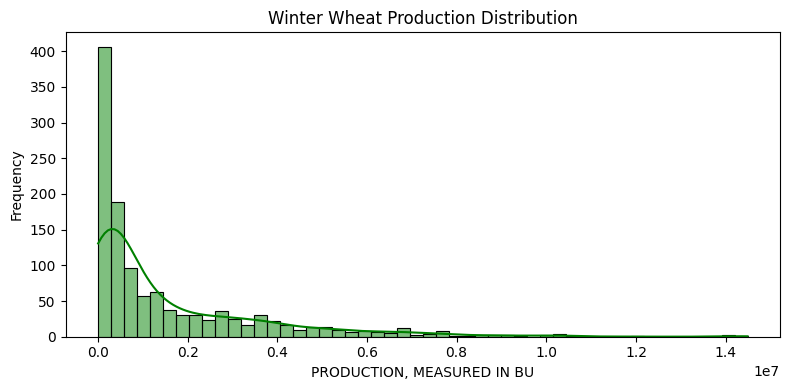

In [13]:
visualize_production_distribution(data=wheat_production_data["PRODUCTION, MEASURED IN BU"], 
                                  x_label="PRODUCTION, MEASURED IN BU", 
                                  title="Winter Wheat Production Distribution")

### 1.2 Load Weather Dataset

In [14]:
selected_counties = []
selected_counties += list(corn_production_data["fips_code"].unique())
selected_counties += list(cotton_production_data["fips_code"].unique())
selected_counties += list(soybeans_production_data["fips_code"].unique())
selected_counties += list(wheat_production_data["fips_code"].unique())
selected_counties = set(selected_counties)
selected_counties = list(selected_counties)

In [15]:
daily_weather_data_selected_states_2017 = helper.load_daily_weather_data(
    weather_data_directory=weather_data_directory,
    selected_states=selected_states.keys(),
    selected_counties=selected_counties,
    year=2017)

In [16]:
daily_weather_data_selected_states_2018 = helper.load_daily_weather_data(
    weather_data_directory=weather_data_directory,
    selected_states=selected_states.keys(), 
    selected_counties=selected_counties,
    year=2018)

In [17]:
daily_weather_data_selected_states_2019 = helper.load_daily_weather_data(
    weather_data_directory=weather_data_directory,
    selected_states=selected_states.keys(),
    selected_counties=selected_counties,
    year=2019)

In [18]:
daily_weather_data_selected_states_2020 = helper.load_daily_weather_data(
    weather_data_directory=weather_data_directory,
    selected_states=selected_states.keys(),
    selected_counties=selected_counties,
    year=2020)

In [19]:
daily_weather_data_selected_states_2021 = helper.load_daily_weather_data(
    weather_data_directory=weather_data_directory,
    selected_states=selected_states.keys(),
    selected_counties=selected_counties, 
    year=2021)

In [20]:
daily_weather_data_selected_states_2022 = helper.load_daily_weather_data(
    weather_data_directory=weather_data_directory,
    selected_states=selected_states.keys(),
    selected_counties=selected_counties,
    year=2022)

In [23]:
def join_all_year_daily_weather_data(yearly_data = []):
    all_years_dataframe = []
    
    for year in yearly_data:
        for _, weather_data in year.items():
            all_years_dataframe.append(weather_data)
    
    return pd.concat(all_years_dataframe, ignore_index=True)

In [24]:
all_years_daily_weather_dataframe = join_all_year_daily_weather_data(yearly_data=[
    daily_weather_data_selected_states_2017, daily_weather_data_selected_states_2018, daily_weather_data_selected_states_2019,
    daily_weather_data_selected_states_2020, daily_weather_data_selected_states_2021, daily_weather_data_selected_states_2022
])

In [25]:
all_years_daily_weather_dataframe

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (K),Min Temperature (K),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,1,1.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,282.594,280.822,0.202,96.6,3.285,3.249,-1.431,-2.724,402.7,0.038
1,2017,1,2.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,290.327,281.778,32.386,96.8,3.221,3.745,-2.626,-0.033,311.9,0.046
2,2017,1,3.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,288.150,284.078,0.335,95.8,3.505,3.055,2.428,0.045,233.6,0.061
3,2017,1,4.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,285.468,272.247,0.254,73.3,7.472,7.812,-0.294,-7.517,2979.4,0.205
4,2017,1,5.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,275.424,272.067,0.017,76.4,3.854,4.546,-2.013,-3.800,287.5,0.150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31552586,2022,12,27.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,291.998,272.679,0.000,43.4,4.136,2.577,-0.884,-0.294,4219.9,0.752
31552587,2022,12,28.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,299.024,274.763,0.000,51.3,5.040,2.511,-1.789,1.027,3998.2,0.835
31552588,2022,12,29.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,296.131,283.523,0.000,74.2,3.630,2.322,-1.572,-1.231,2807.9,0.554
31552589,2022,12,30.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,294.825,282.423,0.087,52.9,3.559,1.852,0.593,-1.298,2131.4,0.886


In [ ]:
# del daily_weather_data_selected_states_2017
# del daily_weather_data_selected_states_2018
# del daily_weather_data_selected_states_2019
# del daily_weather_data_selected_states_2020
# del daily_weather_data_selected_states_2021
# del daily_weather_data_selected_states_2022

# gc.collect()

13518

## 2. Initial Data Processing

### 2.1 Weather Initial Data Processing

#### 2.1.2 Kelvin-Celsius Conversion

In [27]:
def convert_temperature_to_celsius(df, inplace=True):
    if not inplace:
        df_converted = df
    else:
        df_converted = df.copy()
    
    # Define temperature columns to convert
    temp_columns = [
        'Avg Temperature (K)',
        'Max Temperature (K)', 
        'Min Temperature (K)'
    ]
    
    # Convert each temperature column from Kelvin to Celsius
    for col in temp_columns:
        if col in df_converted.columns:
            # K to C conversion: subtract 273.15
            df_converted[col] = df_converted[col] - 273.15
            df_converted[col] = df_converted[col].round(2)
            # Rename column to reflect new units
            new_col_name = col.replace('(K)', '(C)')
            df_converted = df_converted.rename(columns={col: new_col_name})
            
            print(f"Converted {col} to {new_col_name}")
        else:
            print(f"Warning: Column {col} not found in dataset")
    
    return df_converted

In [28]:
all_years_daily_weather_dataframe_converted = convert_temperature_to_celsius(all_years_daily_weather_dataframe, inplace=True)


Converted Avg Temperature (K) to Avg Temperature (C)
Converted Max Temperature (K) to Max Temperature (C)
Converted Min Temperature (K) to Min Temperature (C)


In [ ]:
# del all_years_daily_weather_dataframe

# gc.collect()

38

In [34]:
all_years_daily_weather_dataframe_converted

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (C),Min Temperature (C),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,1,1.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,9.44,7.67,0.202,96.6,3.285,3.249,-1.431,-2.724,402.7,0.038
1,2017,1,2.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,17.18,8.63,32.386,96.8,3.221,3.745,-2.626,-0.033,311.9,0.046
2,2017,1,3.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,15.00,10.93,0.335,95.8,3.505,3.055,2.428,0.045,233.6,0.061
3,2017,1,4.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,12.32,-0.90,0.254,73.3,7.472,7.812,-0.294,-7.517,2979.4,0.205
4,2017,1,5.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,2.27,-1.08,0.017,76.4,3.854,4.546,-2.013,-3.800,287.5,0.150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31552586,2022,12,27.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,18.85,-0.47,0.000,43.4,4.136,2.577,-0.884,-0.294,4219.9,0.752
31552587,2022,12,28.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,25.87,1.61,0.000,51.3,5.040,2.511,-1.789,1.027,3998.2,0.835
31552588,2022,12,29.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,22.98,10.37,0.000,74.2,3.630,2.322,-1.572,-1.231,2807.9,0.554
31552589,2022,12,30.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,21.68,9.27,0.087,52.9,3.559,1.852,0.593,-1.298,2131.4,0.886


#### 2.1.2 Precipitation Renamed Unit

In [35]:
def rename_precipitation_column(df):
    old_column = 'Precipitation (kg m**-2)'
    new_column = 'Precipitation (mm)'
    
    if old_column in df.columns:
        df.rename(columns={old_column: new_column}, inplace=True)
        print(f"Renamed: '{old_column}' → '{new_column}'")
    else:
        print(f"Column '{old_column}' not found")
        print(f"Available columns: {[col for col in df.columns if 'precip' in col.lower()]}")


In [36]:
rename_precipitation_column(all_years_daily_weather_dataframe_converted)

Renamed: 'Precipitation (kg m**-2)' → 'Precipitation (mm)'


#### 2.1.3 Solar Radiation Unit Conversion

In [37]:
def convert_solar_radiation_to_daily(df):
    old_column = 'Downward Shortwave Radiation Flux (W m**-2)'
    new_column = 'Solar Radiation (MJ m**-2 day**-1)'
    
    if old_column in df.columns:
        # Convert W/m² to MJ/m²/day
        df[old_column] = df[old_column] * 0.0864
        
        # Rename column
        df.rename(columns={old_column: new_column}, inplace=True)
        
        print(f"Converted and renamed: '{old_column}' → '{new_column}'")
        print(f"Range: {df[new_column].min():.1f} to {df[new_column].max():.1f} MJ/m²/day")
    else:
        print(f"Column '{old_column}' not found")

In [38]:
convert_solar_radiation_to_daily(all_years_daily_weather_dataframe_converted)

Converted and renamed: 'Downward Shortwave Radiation Flux (W m**-2)' → 'Solar Radiation (MJ m**-2 day**-1)'
Range: 0.0 to 1714.0 MJ/m²/day


#### 2.1.4 Extreme Events Features

In [39]:
def create_stress_indicators(df):
    # Temperature stress indicators
    df['Heat_Stress_Day'] = (df['Max Temperature (C)'] > 35).astype(int) 
    df['Cold_Stress_Day'] = (df['Min Temperature (C)'] < 10).astype(int) 
    
    # Water stress indicators
    df['Drought_Stress_Day'] = (df['Vapor Pressure Deficit (kPa)'] > 2.5).astype(int)  # >2.5 kPa severe stress
    df['Wet_Day'] = (df['Precipitation (mm)'] >= 1.0).astype(int)         # ≥1mm considered wet
    df['Heavy_Rain_Day'] = (df['Precipitation (mm)'] >= 25).astype(int)   # ≥25mm heavy rain
    
    # Light stress indicator
    df['Low_Light_Day'] = (df['Solar Radiation (MJ m**-2 day**-1)'] < 10).astype(int)  # <10 MJ/m²/day low

In [40]:
create_stress_indicators(all_years_daily_weather_dataframe_converted)

In [41]:
all_years_daily_weather_dataframe_converted

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,U Component of Wind (m s**-1),V Component of Wind (m s**-1),Solar Radiation (MJ m**-2 day**-1),Vapor Pressure Deficit (kPa),Heat_Stress_Day,Cold_Stress_Day,Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Low_Light_Day
0,2017,1,1.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,-1.431,-2.724,34.79328,0.038,0,1,0,0,0,0
1,2017,1,2.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,-2.626,-0.033,26.94816,0.046,0,1,0,1,1,0
2,2017,1,3.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,2.428,0.045,20.18304,0.061,0,0,0,0,0,0
3,2017,1,4.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,-0.294,-7.517,257.42016,0.205,0,1,0,0,0,0
4,2017,1,5.0,Daily,ARKANSAS,ARKANSAS,05001,0.0,34.159311,-91.711795,...,-2.013,-3.800,24.84000,0.150,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31552586,2022,12,27.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,-0.884,-0.294,364.59936,0.752,0,1,0,0,0,0
31552587,2022,12,28.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,-1.789,1.027,345.44448,0.835,0,1,0,0,0,0
31552588,2022,12,29.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,-1.572,-1.231,242.60256,0.554,0,0,0,0,0,0
31552589,2022,12,30.0,Daily,TEXAS,ZAVALA,48507,27.0,28.978643,-99.509780,...,0.593,-1.298,184.15296,0.886,0,1,0,0,0,0


### 2.1.5 Yearly Weather Data Aggregation

In [42]:
import pandas as pd

def aggregate_weather_by_growing_season(df, year):
    year_data = df[df['Year'] == year].copy()
    
    if len(year_data) == 0:
        print(f"No data found for year {year}")
        return pd.DataFrame()
    
    results = []
    
    for state in year_data['State'].unique():
        state_data = year_data[year_data['State'] == state].copy()
        
        # First aggregate by county and grid (daily level), then by county (seasonal level)
        # Step 1: Aggregate across grid points for each county-day (take mean across grids)
        daily_county = state_data.groupby(['State', 'County', 'FIPS Code', 'Year', 'Month', 'Day']).agg({
            'Avg Temperature (C)': 'mean',
            'Max Temperature (C)': 'mean', 
            'Min Temperature (C)': 'mean',
            'Heat_Stress_Day': 'mean',              # Proportion of grids with heat stress
            'Cold_Stress_Day': 'mean',
            'Precipitation (mm)': 'mean',           # Average precipitation across grids
            'Vapor Pressure Deficit (kPa)': 'mean',
            'Drought_Stress_Day': 'mean',
            'Wet_Day': 'mean',
            'Heavy_Rain_Day': 'mean',
            'Solar Radiation (MJ m**-2 day**-1)': 'mean',
            'Low_Light_Day': 'mean',
            'Relative Humidity (%)': 'mean',
            'Wind Speed (m s**-1)': 'mean'
        }).reset_index()
        
        # Step 2: Aggregate daily county averages to yearly aggregates
        county_aggregates = daily_county.groupby(['State', 'County', 'FIPS Code']).agg({
            # Temperature variables
            'Avg Temperature (C)': 'mean',          # Average temperature
            'Max Temperature (C)': 'max',           # Maximum temperature reached
            'Min Temperature (C)': 'min',           # Minimum temperature reached
            'Heat_Stress_Day': 'sum',               # Number of heat stress days
            'Cold_Stress_Day': 'sum',               # Number of cold stress days
            
            # Water variables  
            'Precipitation (mm)': 'sum',            # Total precipitation
            'Vapor Pressure Deficit (kPa)': 'mean', # Average VPD
            'Drought_Stress_Day': 'sum',            # Number of drought stress days
            'Wet_Day': 'sum',                       # Number of wet days
            'Heavy_Rain_Day': 'sum',                # Number of heavy rain days
            
            # Radiation
            'Solar Radiation (MJ m**-2 day**-1)': 'sum',  # Total solar radiation
            'Low_Light_Day': 'sum',                 # Number of low light days
            
            # Other
            'Relative Humidity (%)': 'mean',        # Average humidity
            'Wind Speed (m s**-1)': 'mean'          # Average wind speed
        }).reset_index()
        
        # Add year and season info
        county_aggregates['Year'] = year
        results.append(county_aggregates)
    
    if results:
        final_result = pd.concat(results, ignore_index=True)
        print(f"Aggregated {year} growing season data:")
        print(f"  Counties: {len(final_result)}")
        print(f"  States: {final_result['State'].nunique()}")
        return final_result
    else:
        print(f"No growing season data created for {year}")
        return pd.DataFrame()

def aggregate_all_years(df_weather):
    years = sorted(df_weather['Year'].unique())
    print(f"Processing years: {years}")
    
    # Process each year
    all_years_data = []
    for year in years:
        yearly_data = aggregate_weather_by_growing_season(df_weather, year)
        if not yearly_data.empty:
            all_years_data.append(yearly_data)
    
    if all_years_data:
        final_dataset = pd.concat(all_years_data, ignore_index=True)
        print(f"Final aggregated dataset:")
        print(f"  Total county-years: {len(final_dataset):,}")
        print(f"  Years: {final_dataset['Year'].nunique()}")
        print(f"  Counties: {final_dataset['County'].nunique()}")
        print(f"  States: {final_dataset['State'].nunique()}")
        
        # Show summary of key variables
        print(f"Key variable ranges:")
        print(f"  Total Precipitation: {final_dataset['Precipitation (mm)'].min():.0f} to {final_dataset['Precipitation (mm)'].max():.0f} mm")
        print(f"  Heat Stress Days: {final_dataset['Heat_Stress_Day'].min():.0f} to {final_dataset['Heat_Stress_Day'].max():.0f}")
        
        return final_dataset
    else:
        print("No data processed")
        return pd.DataFrame()

In [50]:
final_aggregates_df_weather = aggregate_all_years(all_years_daily_weather_dataframe_converted)

Processing years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Aggregated 2017 growing season data:
  Counties: 436
  States: 6
Aggregated 2018 growing season data:
  Counties: 436
  States: 6
Aggregated 2019 growing season data:
  Counties: 436
  States: 6
Aggregated 2020 growing season data:
  Counties: 436
  States: 6
Aggregated 2021 growing season data:
  Counties: 436
  States: 6
Aggregated 2022 growing season data:
  Counties: 436
  States: 6
Final aggregated dataset:
  Total county-years: 2,616
  Years: 6
  Counties: 394
  States: 6
Key variable ranges:
  Total Precipitation: 48 to 2747 mm
  Heat Stress Days: 0 to 157


In [51]:
final_aggregates_df_weather

,State,County,FIPS Code,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year
0,ARKANSAS,ARKANSAS,05001,17.778272,35.917027,-11.813784,5.567568,127.891892,1652.416135,0.696802,0.000000,104.648649,18.864865,126087.217712,5.918919,71.964857,5.487101,2017
1,ARKANSAS,ASHLEY,05003,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017
2,ARKANSAS,BENTON,05007,15.453959,34.335484,-14.454839,0.258065,160.032258,1423.562871,0.603967,0.000000,87.258065,18.870968,125762.313488,8.129032,71.757923,2.907717,2017
3,ARKANSAS,CHICOT,05017,18.669693,35.024000,-8.272000,1.200000,100.933333,1869.680867,0.641058,0.000000,112.333333,25.666667,127958.411779,9.200000,74.422411,5.543904,2017
4,ARKANSAS,CLAY,05021,16.135538,35.586250,-11.329375,3.375000,149.125000,1388.596562,0.616330,0.000000,104.312500,13.937500,130721.404219,7.687500,72.694829,4.815941,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2611,TEXAS,WILSON,48493,21.392574,41.521429,-7.938214,104.214286,95.928571,329.569571,1.156840,3.892857,37.928571,3.142857,154536.885121,15.178571,63.404912,4.083249,2022
2612,TEXAS,WISE,48497,18.878895,43.502500,-12.648500,77.500000,130.000000,574.534350,1.242541,41.300000,43.050000,6.850000,155632.124477,15.000000,56.900205,3.706686,2022
2613,TEXAS,YOAKUM,48501,16.195158,40.266875,-15.552500,55.875000,170.812500,188.818000,1.350214,54.375000,30.875000,0.437500,176941.193213,12.687500,46.753596,4.302007,2022
2614,TEXAS,YOUNG,48503,18.872568,42.995500,-12.215500,90.050000,132.400000,480.968900,1.353276,52.850000,39.600000,5.350000,161921.670365,14.950000,53.675644,3.951855,2022


## 3. Correlation Analysis

In [66]:
# Compute correlation matrix
def visualize_correlation_bar_chart(corr_matrix, target_col, title=""):

    target_corr = corr_matrix[target_col].drop(target_col).sort_values()  # drop itself

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=target_corr.values,
        y=target_corr.index,
        palette='coolwarm',
    )
    
    ax.set_xlim(-1, 1)

    for i, (value, name) in enumerate(zip(target_corr.values, target_corr.index)):
        ax.text(
            value + 0.01 if value > 0 else value - 0.01,  # slight offset
            i,
            f"{value:.2f}",
            color='black',
            va='center',
            ha='left' if value > 0 else 'right',
            fontsize=8
        )


    plt.title(title, fontsize=14)
    plt.xlabel(f"Correlation Coefficient to ({target_col})")
    plt.ylabel("Feature")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout(pad=3.0)  # Add more padding inside the figure
    plt.show()
    
def get_selected_columns_for_corr_matrix(crop_type):
    target_columns = "PRODUCTION, MEASURED IN BU"
    if crop_type == "COTTON":
        target_columns = "PRODUCTION, MEASURED IN 480 LB BALES"


    # Optional: define weather-related columns explicitly
    feature_columns = [
        'Avg Temperature (C)', 'Max Temperature (C)', 'Min Temperature (C)',
        'Heat_Stress_Day', 'Cold_Stress_Day', 'Precipitation (mm)',
        'Vapor Pressure Deficit (kPa)', 'Drought_Stress_Day', 'Wet_Day',
        'Heavy_Rain_Day', 'Solar Radiation (MJ m**-2 day**-1)',
        'Low_Light_Day', 'Relative Humidity (%)', 'Wind Speed (m s**-1)',
        # 'harvested_area'
    ]
    
    

    # Select only weather + target
    selected_columns = feature_columns + [target_columns]
    return selected_columns

def visualize_correlation_heatmap(correlation_matrix):
    plt.figure(figsize=(16, 16))
    sns.heatmap(correlation_matrix,
                xticklabels=correlation_matrix.columns,
                yticklabels=correlation_matrix.columns,
                annot=True,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='.2f')
    
    plt.title('Correlation Matrix Heatmap')
    plt.tight_layout()
    plt.show()
    
def multicollinearity_table(corr_matrix, threshold=0.8):
    # Find high correlations
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) >= threshold:
                high_corr_pairs.append({
                    'Feature_1': corr_matrix.columns[i],
                    'Feature_2': corr_matrix.columns[j],
                    'Correlation': round(corr_val, 3),
                    'Abs_Correlation': round(abs(corr_val), 3)
                })
    
    # Create DataFrame
    if high_corr_pairs:
        result_df = pd.DataFrame(high_corr_pairs)
        result_df = result_df.sort_values('Abs_Correlation', ascending=False)
        return result_df
    else:
        return pd.DataFrame(columns=['Feature_1', 'Feature_2', 'Correlation', 'Abs_Correlation'])

### 3.1 Weather - Corn Production Correlation Analysis

In [53]:
merged_weather_and_corn_production_data = pd.merge(final_aggregates_df_weather, 
                                              corn_production_data[['PRODUCTION, MEASURED IN BU', 'year', 'fips_code', 'harvested_area']], 
                                              left_on=['Year', 'FIPS Code'],
                                              right_on=['year', 'fips_code'])

In [54]:
# merged_weather_and_corn_production_data.drop(["year", "fips_code"], axis=1).to_csv("./aggregated_dataset/merged_weather_and_corn_production_data.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7400\4156005601.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


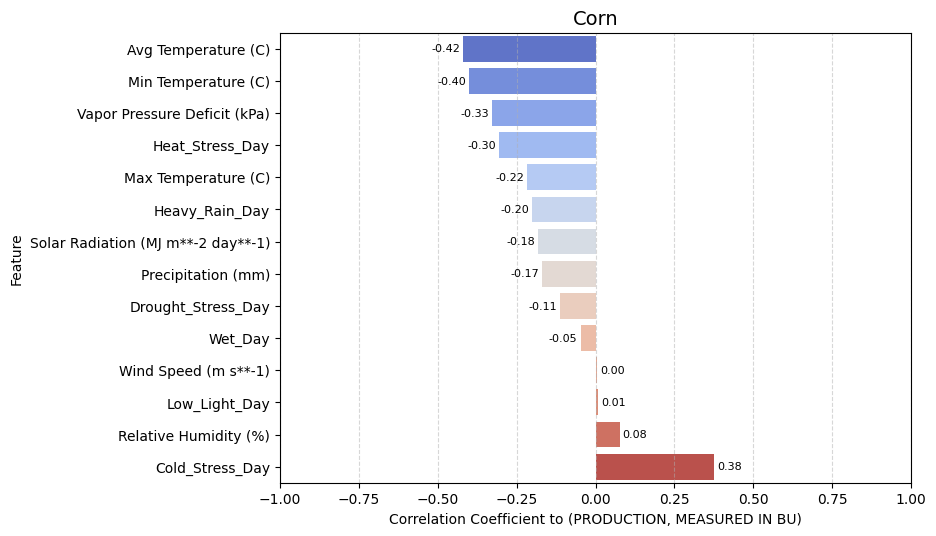

,Feature_1,Feature_2,Correlation,Abs_Correlation
5,Precipitation (mm),Heavy_Rain_Day,0.976,0.976
1,Avg Temperature (C),Cold_Stress_Day,-0.958,0.958
0,Avg Temperature (C),Min Temperature (C),0.912,0.912
4,Precipitation (mm),Wet_Day,0.876,0.876
2,Min Temperature (C),Cold_Stress_Day,-0.863,0.863
3,Heat_Stress_Day,Vapor Pressure Deficit (kPa),0.860,0.860


In [67]:
corn_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("CORN")
weather_corn_corr_dataframe = merged_weather_and_corn_production_data[corn_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_corn_corr_dataframe.corr(), "PRODUCTION, MEASURED IN BU", "Corn")
multicollinearity_table(weather_corn_corr_dataframe.corr())

### 3.2 Weather - Cotton Production Correlation Analysis

In [70]:
merged_weather_and_cotton_production_data = pd.merge(final_aggregates_df_weather, 
                                              cotton_production_data[['PRODUCTION, MEASURED IN 480 LB BALES', 'year', 'fips_code', 'harvested_area']], 
                                              left_on=['Year', 'FIPS Code'],
                                              right_on=['year', 'fips_code'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7400\4156005601.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


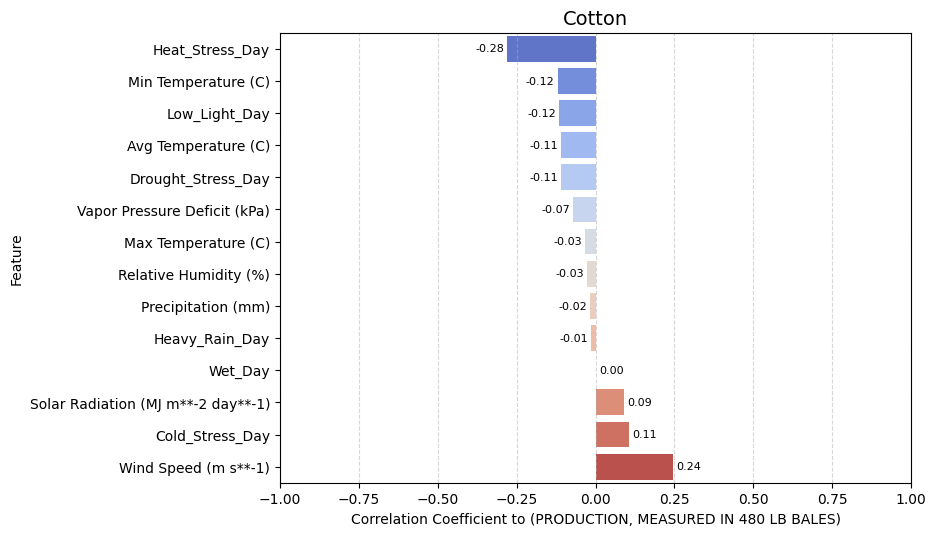

,Feature_1,Feature_2,Correlation,Abs_Correlation
3,Precipitation (mm),Heavy_Rain_Day,0.980,0.980
0,Avg Temperature (C),Cold_Stress_Day,-0.969,0.969
2,Precipitation (mm),Wet_Day,0.924,0.924
7,Vapor Pressure Deficit (kPa),Relative Humidity (%),-0.898,0.898
10,Wet_Day,Relative Humidity (%),0.863,0.863
8,Wet_Day,Heavy_Rain_Day,0.862,0.862
5,Vapor Pressure Deficit (kPa),Drought_Stress_Day,0.862,0.862
6,Vapor Pressure Deficit (kPa),Wet_Day,-0.821,0.821
9,Wet_Day,Solar Radiation (MJ m**-2 day**-1),-0.818,0.818
1,Max Temperature (C),Vapor Pressure Deficit (kPa),0.808,0.808


In [74]:
cotton_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("COTTON")
weather_cotton_corr_dataframe = merged_weather_and_cotton_production_data[cotton_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_cotton_corr_dataframe.corr(), "PRODUCTION, MEASURED IN 480 LB BALES", "Cotton")
multicollinearity_table(weather_cotton_corr_dataframe.corr())

### 3.3 Weather - Soybeans Production Correlation Analysis

In [75]:
merged_weather_and_soybeans_production_data = pd.merge(final_aggregates_df_weather, 
                                              soybeans_production_data[['PRODUCTION, MEASURED IN BU', 'year', 'fips_code', 'harvested_area']], 
                                              left_on=['Year', 'FIPS Code'],
                                              right_on=['year', 'fips_code'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7400\4156005601.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


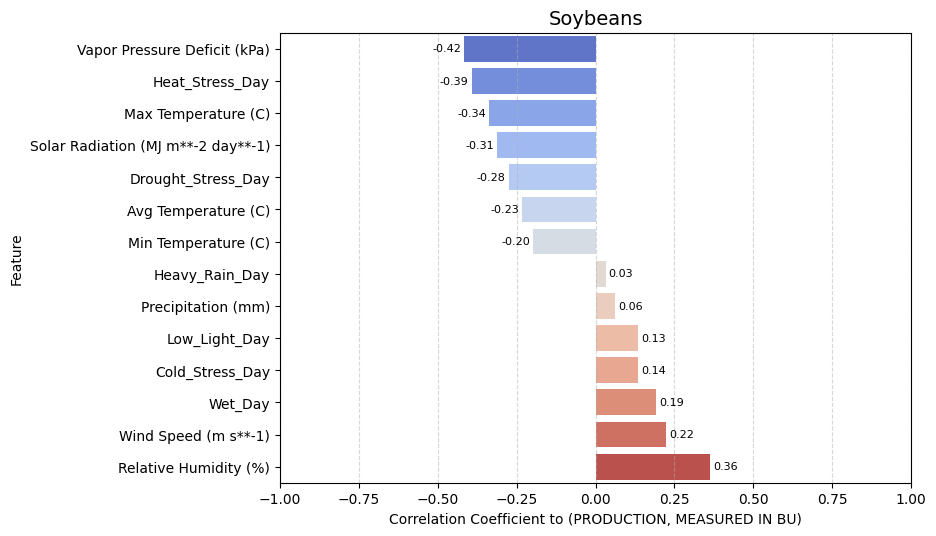

,Feature_1,Feature_2,Correlation,Abs_Correlation
5,Precipitation (mm),Heavy_Rain_Day,0.978,0.978
1,Avg Temperature (C),Cold_Stress_Day,-0.956,0.956
0,Avg Temperature (C),Min Temperature (C),0.897,0.897
4,Precipitation (mm),Wet_Day,0.874,0.874
3,Heat_Stress_Day,Vapor Pressure Deficit (kPa),0.872,0.872
2,Min Temperature (C),Cold_Stress_Day,-0.867,0.867


In [76]:
soybeans_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("SOYBEANS")
weather_soybeans_corr_dataframe = merged_weather_and_soybeans_production_data[soybeans_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_soybeans_corr_dataframe.corr(), "PRODUCTION, MEASURED IN BU", "Soybeans")
multicollinearity_table(weather_soybeans_corr_dataframe.corr())

### 3.3 Weather - Winter Wheat Production Correlation Analysis

In [77]:
merged_weather_and_wheat_production_data = pd.merge(final_aggregates_df_weather, 
                                              wheat_production_data[['PRODUCTION, MEASURED IN BU', 'year', 'fips_code', 'harvested_area']], 
                                              left_on=['Year', 'FIPS Code'],
                                              right_on=['year', 'fips_code'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7400\4156005601.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


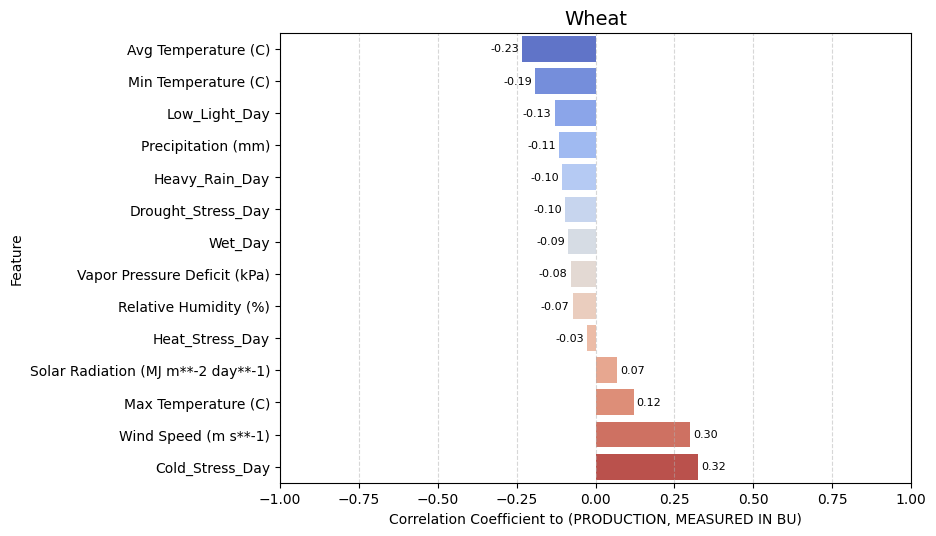

,Feature_1,Feature_2,Correlation,Abs_Correlation
3,Precipitation (mm),Heavy_Rain_Day,0.976,0.976
0,Avg Temperature (C),Cold_Stress_Day,-0.941,0.941
2,Precipitation (mm),Wet_Day,0.900,0.900
1,Heat_Stress_Day,Vapor Pressure Deficit (kPa),0.870,0.870
4,Vapor Pressure Deficit (kPa),Drought_Stress_Day,0.840,0.840
5,Vapor Pressure Deficit (kPa),Relative Humidity (%),-0.835,0.835
7,Wet_Day,Relative Humidity (%),0.833,0.833
6,Wet_Day,Heavy_Rain_Day,0.832,0.832


In [79]:
wheat_corr_matrix_selected_columns = get_selected_columns_for_corr_matrix("SOYBEANS")
weather_wheat_corr_dataframe = merged_weather_and_wheat_production_data[wheat_corr_matrix_selected_columns].copy()
visualize_correlation_bar_chart(weather_wheat_corr_dataframe.corr(), "PRODUCTION, MEASURED IN BU", "Wheat")
multicollinearity_table(weather_wheat_corr_dataframe.corr())

## 4. Outliers Detection

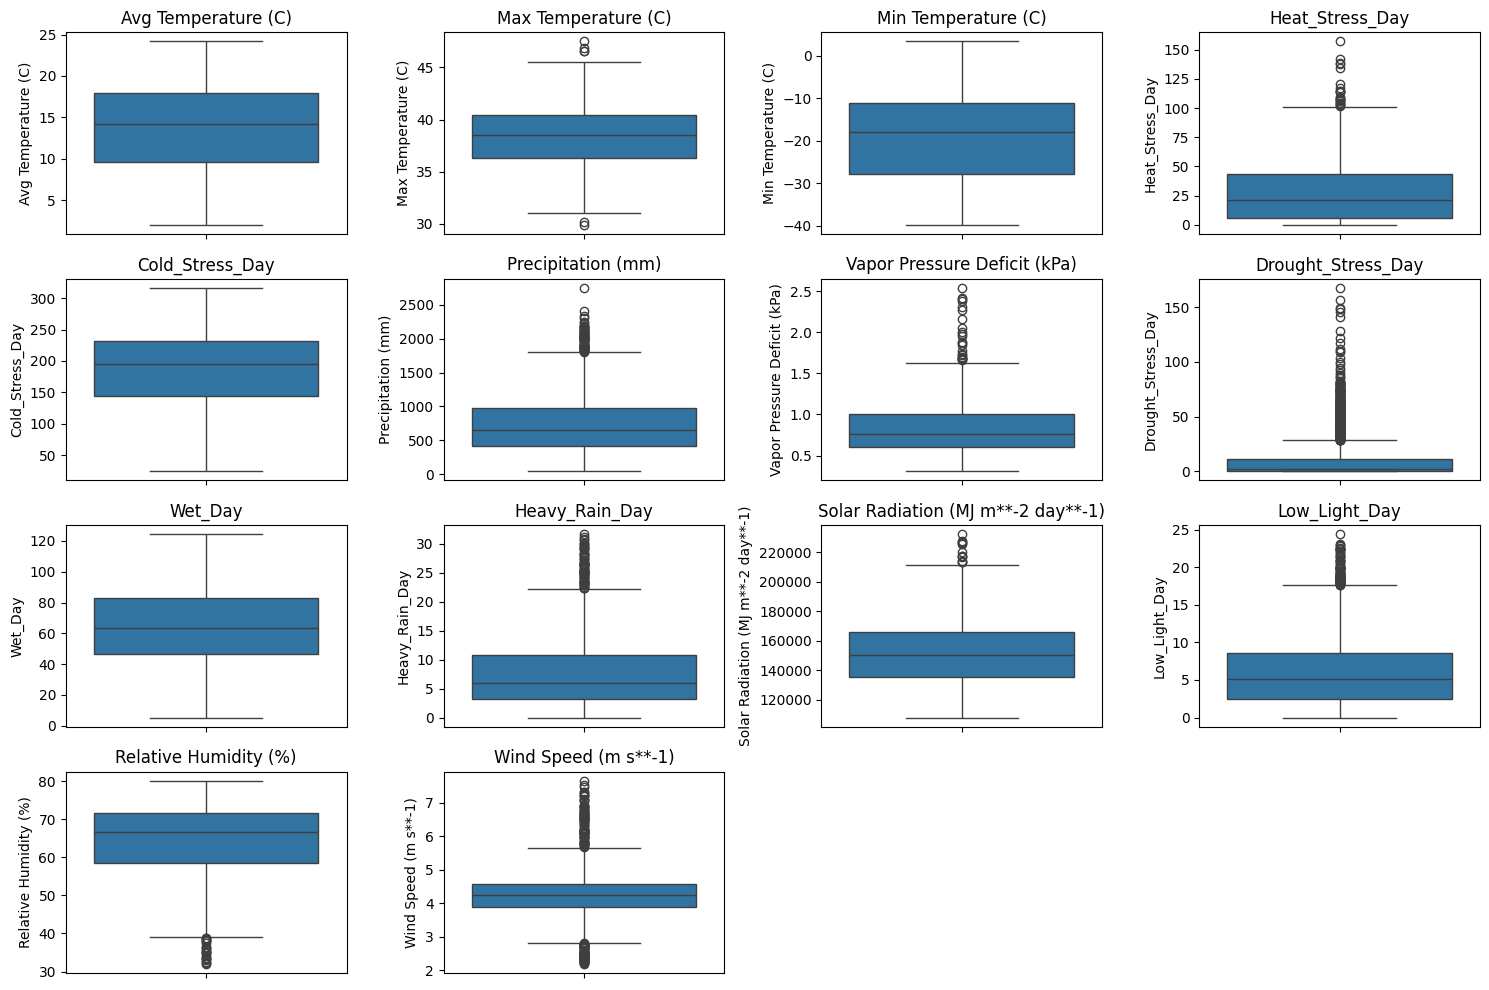

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
weather_columns = [
    'Avg Temperature (C)', 'Max Temperature (C)', 'Min Temperature (C)', 
    'Heat_Stress_Day', 'Cold_Stress_Day', 'Precipitation (mm)', 
    'Vapor Pressure Deficit (kPa)', 'Drought_Stress_Day', 'Wet_Day', 
    'Heavy_Rain_Day', 'Solar Radiation (MJ m**-2 day**-1)', 'Low_Light_Day', 
    'Relative Humidity (%)', 'Wind Speed (m s**-1)'
]

# Set up the figure size
plt.figure(figsize=(15, 10))

# Create boxplots for each weather attribute using a loop
for i, col in enumerate(weather_columns, 1):
    plt.subplot(4, 4, i)  # 4 rows x 4 columns grid
    sns.boxplot(y=final_aggregates_df_weather[col])
    plt.title(col)
    plt.tight_layout()

plt.show()


In [63]:
import pandas as pd

def detect_outliers_iqr_with_columns(df, columns):
    outlier_info = []  # to collect row index and columns that are outliers

    for idx, row in df.iterrows():
        outlier_cols = []
        for col in columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            val = row[col]
            if val < lower_bound or val > upper_bound:
                outlier_cols.append(col)
        
        if outlier_cols:
            outlier_info.append({'index': idx, 'outlier_columns': outlier_cols})
    
    # Create a DataFrame with outlier row indices and columns flagged
    outlier_df = pd.DataFrame(outlier_info).set_index('index')
    return outlier_df

weather_columns = [
    'Avg Temperature (C)', 'Max Temperature (C)', 'Min Temperature (C)', 
    'Heat_Stress_Day', 'Cold_Stress_Day', 'Precipitation (mm)', 
    'Vapor Pressure Deficit (kPa)', 'Drought_Stress_Day', 'Wet_Day', 
    'Heavy_Rain_Day', 'Solar Radiation (MJ m**-2 day**-1)', 'Low_Light_Day', 
    'Relative Humidity (%)', 'Wind Speed (m s**-1)'
]

outliers = detect_outliers_iqr_with_columns(final_aggregates_df_weather, weather_columns)

print(f"Number of rows with outliers: {len(outliers)}")
print(outliers.head())

# To view the full rows with the columns flagged:
outlier_rows = final_aggregates_df_weather.loc[outliers.index]
outlier_rows['outlier_columns'] = outliers['outlier_columns']

outlier_rows


Number of rows with outliers: 628
                              outlier_columns
index                                        
1        [Precipitation (mm), Heavy_Rain_Day]
3        [Precipitation (mm), Heavy_Rain_Day]
7                      [Wind Speed (m s**-1)]
13     [Heavy_Rain_Day, Wind Speed (m s**-1)]
18                     [Wind Speed (m s**-1)]


,State,County,FIPS Code,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,outlier_columns
index,,,,,,,,,,,,,,,,,,,
1,ARKANSAS,ASHLEY,05003,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,"[Precipitation (mm), Heavy_Rain_Day]"
3,ARKANSAS,CHICOT,05017,18.669693,35.024000,-8.272000,1.200000,100.933333,1869.680867,0.641058,0.000000,112.333333,25.666667,127958.411779,9.200000,74.422411,5.543904,2017,"[Precipitation (mm), Heavy_Rain_Day]"
7,ARKANSAS,CRAWFORD,05033,16.349155,34.252381,-15.435238,1.095238,147.523810,1607.639524,0.622999,0.000000,98.476190,20.571429,128647.711802,9.380952,71.759204,2.471969,2017,[Wind Speed (m s**-1)]
13,ARKANSAS,FRANKLIN,05047,16.493342,34.757059,-15.355882,2.529412,143.764706,1690.261588,0.619391,0.000000,101.352941,22.352941,127752.461793,10.529412,72.356422,2.460203,2017,"[Heavy_Rain_Day, Wind Speed (m s**-1)]"
18,ARKANSAS,JOHNSON,05071,16.215586,34.173158,-13.654211,0.631579,144.947368,1701.335263,0.574109,0.000000,107.052632,20.052632,127621.104209,10.315789,73.042653,2.322720,2017,[Wind Speed (m s**-1)]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2611,TEXAS,WILSON,48493,21.392574,41.521429,-7.938214,104.214286,95.928571,329.569571,1.156840,3.892857,37.928571,3.142857,154536.885121,15.178571,63.404912,4.083249,2022,[Heat_Stress_Day]
2612,TEXAS,WISE,48497,18.878895,43.502500,-12.648500,77.500000,130.000000,574.534350,1.242541,41.300000,43.050000,6.850000,155632.124477,15.000000,56.900205,3.706686,2022,[Drought_Stress_Day]
2613,TEXAS,YOAKUM,48501,16.195158,40.266875,-15.552500,55.875000,170.812500,188.818000,1.350214,54.375000,30.875000,0.437500,176941.193213,12.687500,46.753596,4.302007,2022,[Drought_Stress_Day]


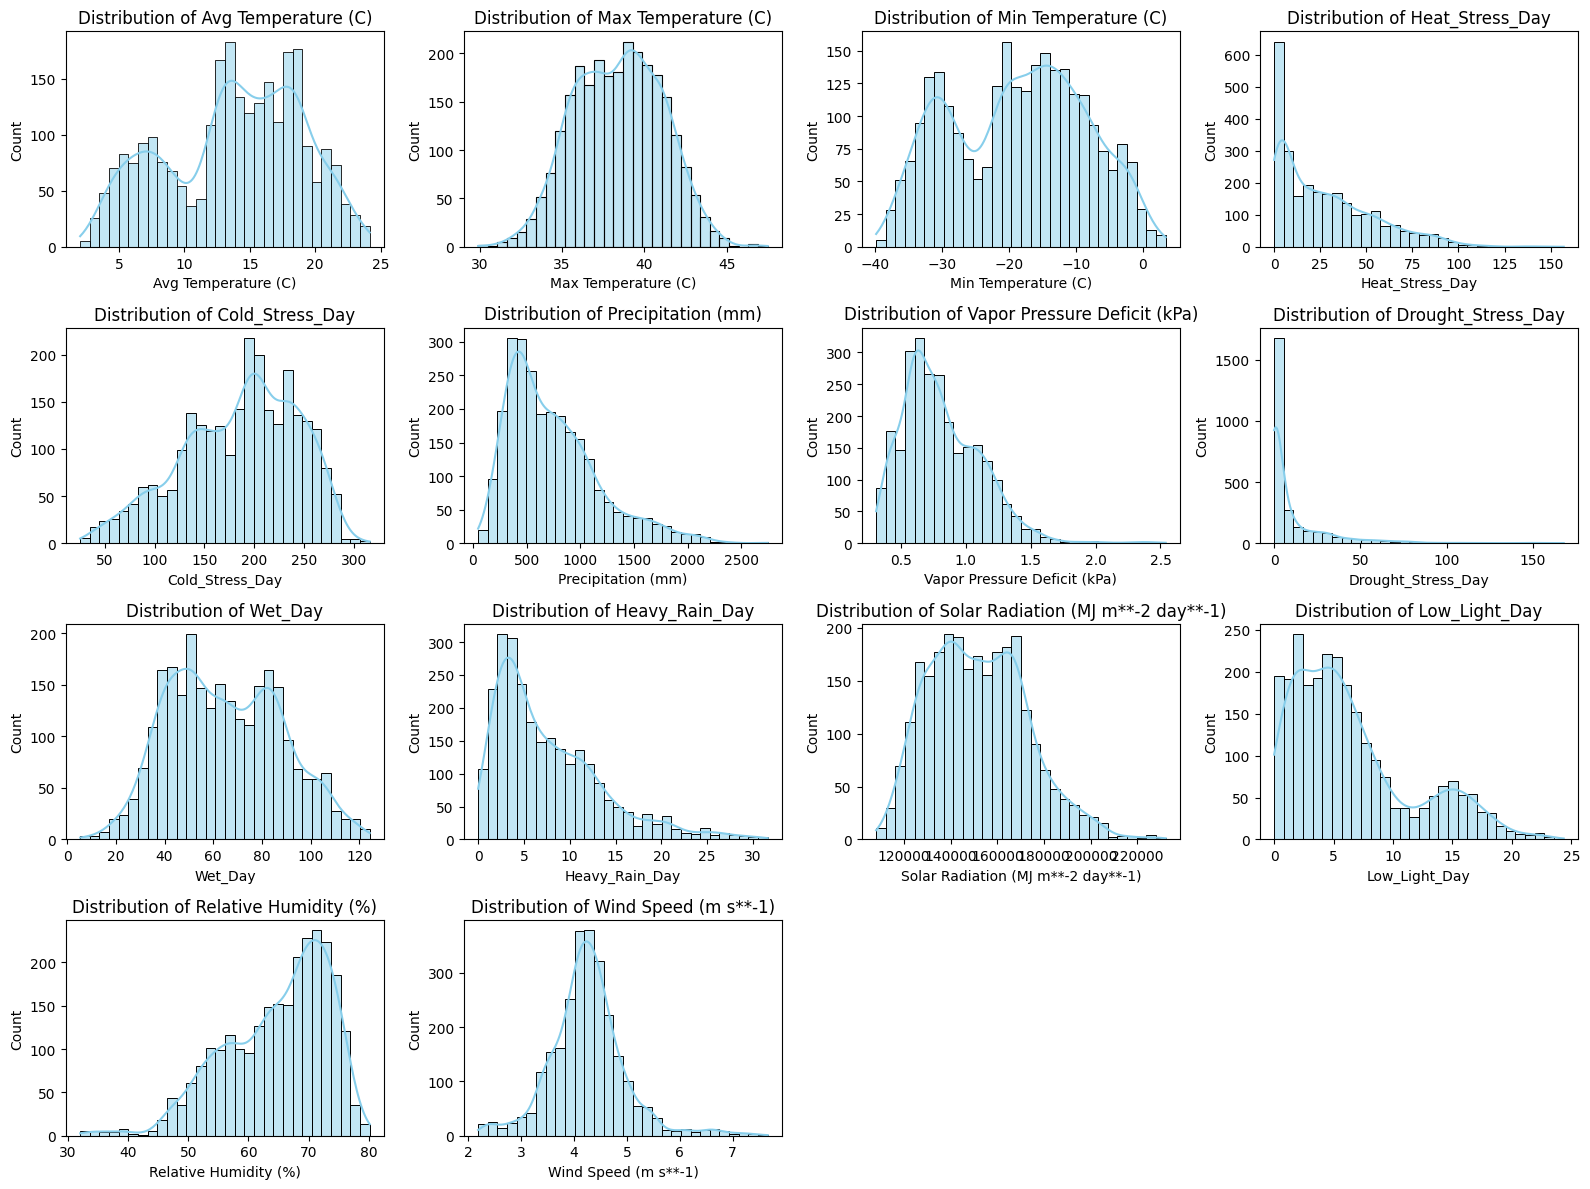

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

weather_columns = [
    'Avg Temperature (C)', 'Max Temperature (C)', 'Min Temperature (C)', 
    'Heat_Stress_Day', 'Cold_Stress_Day', 'Precipitation (mm)', 
    'Vapor Pressure Deficit (kPa)', 'Drought_Stress_Day', 'Wet_Day', 
    'Heavy_Rain_Day', 'Solar Radiation (MJ m**-2 day**-1)', 'Low_Light_Day', 
    'Relative Humidity (%)', 'Wind Speed (m s**-1)'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(weather_columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(final_aggregates_df_weather[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()
